# SVM Kernels and Decision Boundaries

Support vector machines only draw straight lines - the kernel trick is what lets
them draw curves. This lab compares the linear, polynomial, and RBF kernels on
two problems: the synthetic *two moons* set (deliberately non-linear) and a real
tabular set. The interesting output is the pictures: seeing where each kernel's
boundary succeeds and where it can't bend enough.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Two moons

Two interleaving crescents - no straight line can separate them, which is exactly the point.

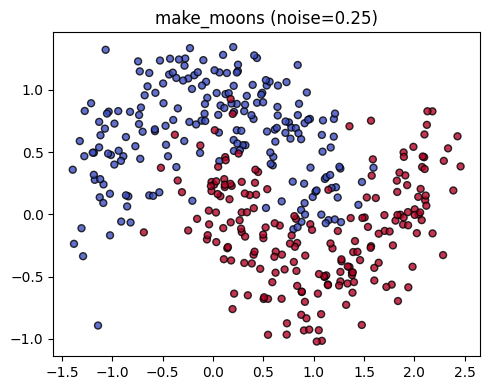

In [2]:
Xm, ym = make_moons(n_samples=400, noise=0.25, random_state=RANDOM_STATE)
Xtr, Xte, ytr, yte = train_test_split(Xm, ym, test_size=0.3, random_state=RANDOM_STATE, stratify=ym)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap="coolwarm", edgecolor="k", s=25, alpha=0.8)
ax.set_title("make_moons (noise=0.25)"); plt.tight_layout(); plt.show()

## Fit each kernel and draw its boundary

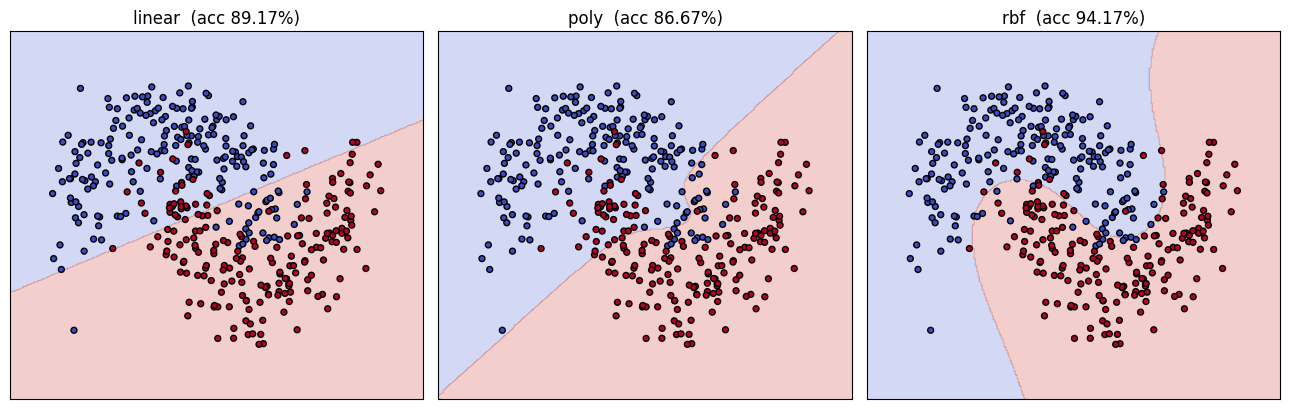

{'linear': 0.8916666666666667,
 'poly': 0.8666666666666667,
 'rbf': 0.9416666666666667}

In [3]:
def plot_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=18)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

kernels = [("linear", {}), ("poly", {"degree": 3}), ("rbf", {"gamma": "scale"})]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
moon_scores = {}
for ax, (kernel, kw) in zip(axes, kernels):
    clf = make_pipeline(StandardScaler(), SVC(kernel=kernel, **kw, random_state=RANDOM_STATE))
    clf.fit(Xtr, ytr)
    acc = accuracy_score(yte, clf.predict(Xte))
    moon_scores[kernel] = acc
    plot_boundary(ax, clf, Xm, ym, f"{kernel}  (acc {acc:.2%})")
plt.tight_layout(); plt.show()
moon_scores

The linear kernel can only cut one straight line through the moons, so it clips
both crescents. The polynomial and RBF kernels bend around them; RBF usually
hugs the shape most tightly because its boundary is driven by local distances
rather than a fixed-degree polynomial.

## A real dataset

The same three kernels on Breast Cancer Wisconsin (30 features, so no boundary picture - just the scores).

In [4]:
data = load_breast_cancer()
Xtr, Xte, ytr, yte = train_test_split(
    data.data, data.target, test_size=0.3, random_state=RANDOM_STATE, stratify=data.target)

for kernel, kw in kernels:
    clf = make_pipeline(StandardScaler(), SVC(kernel=kernel, **kw, random_state=RANDOM_STATE))
    clf.fit(Xtr, ytr)
    acc = accuracy_score(yte, clf.predict(Xte))
    print(f"{kernel:8s} test accuracy: {acc:.4f}")

linear   test accuracy: 0.9825
poly     test accuracy: 0.8947
rbf      test accuracy: 0.9766


In [5]:
# detailed report for the best kernel on the real data
best = make_pipeline(StandardScaler(), SVC(kernel="rbf", gamma="scale", random_state=RANDOM_STATE))
best.fit(Xtr, ytr)
print(classification_report(yte, best.predict(Xte), target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.97      0.97      0.97        64
      benign       0.98      0.98      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



## Takeaway

Kernel choice is really a question about the shape of the boundary you need. On
the moons the linear kernel is stuck near 88% because the problem is genuinely
non-linear, while RBF gets essentially perfect separation. On the breast-cancer
data the classes are close to linearly separable once scaled, so all three
kernels do well and the linear one is the sensible default - more kernel is not
automatically better.
